# Dataset Inspection — Min-Fuel Trajectory Sample
Load a random sample from the first chunk and visualize the 3D trajectory, state evolution, and costate evolution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

dataset_dir = Path("earth_mars_minfuel_posvel_constrained_32pts")
meta = np.load(dataset_dir / "metadata.npz")
chunk = np.load(sorted(dataset_dir.glob("chunk_*.npz"))[7])

time_grid = meta["time_grid"]
print(f"num_points={len(time_grid)}, t_final={meta['t_final']:.4f}")
print(f"chunk keys: {list(chunk.keys())}")
print(f"states: {chunk['states'].shape}, costates: {chunk['costates'].shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'earth_mars_minfuel_posvel_constrained_32pts/metadata.npz'

In [ ]:
# Pick a random sample
import random
rng = np.random.default_rng(random.randint(0, 100000))
idx = rng.integers(0, chunk["states"].shape[0])
print(f"Sample index: {idx}")

states = chunk["states"][idx]        # (32, 7) — r_x, r_y, r_z, v_x, v_y, v_z, m
costates = chunk["costates"][idx]    # (32, 7) — λ_r(3), λ_v(3), λ_m

r = states[:, :3]
v = states[:, 3:6]
mass = states[:, 6]
lam_r = costates[:, :3]
lam_v = costates[:, 3:6]
lam_m = costates[:, 6]

Sample index: 2162


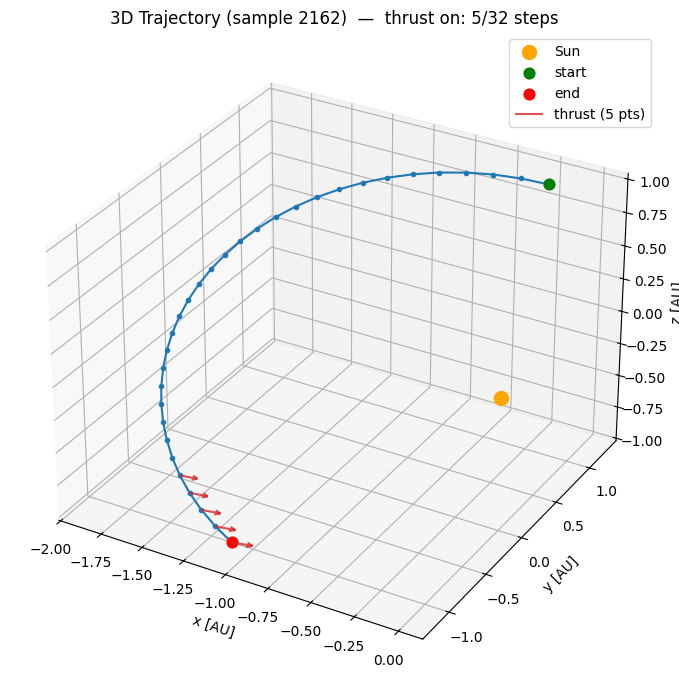

In [ ]:

from core import build_normalization

norm    = build_normalization()
c_val   = norm["c_norm"]
eps_val = float(meta["eps"]) if "eps" in meta else 1e-4

# Optimal thrust from Pontryagin's minimum principle (matches dynamics.py)
lam_v_norm = np.linalg.norm(lam_v, axis=1)                        # (T,)
S     = c_val * lam_v_norm / mass + lam_m - 1                     # switching function
delta = 0.5 * (1.0 + S / np.sqrt(S**2 + eps_val))                 # throttle ∈ (0, 1)
alpha = -lam_v / (lam_v_norm[:, None] + 1e-30)                    # thrust direction unit vector

on = delta > 0.5   # engine nominally on

# 3D Trajectory
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter3D(0, 0, 0, color="orange", s=100, label="Sun", zorder=5)
ax.plot(r[:, 0], r[:, 1], r[:, 2], "o-", markersize=3, linewidth=1.5, color="tab:blue")
ax.scatter(*r[0], color="green", s=60, zorder=5, label="start")
ax.scatter(*r[-1], color="red", s=60, zorder=5, label="end")

if np.any(on):
    scale = 0.08 * np.ptp(r, axis=0).max()   # ~8% of trajectory extent
    ax.quiver(
        r[on, 0], r[on, 1], r[on, 2],
        alpha[on, 0], alpha[on, 1], alpha[on, 2],
        length=scale, normalize=True,
        color="tab:red", alpha=0.8, label=f"thrust ({on.sum()} pts)",
    )

ax.set_xlabel("x [AU]")
ax.set_ylabel("y [AU]")
ax.set_zlabel("z [AU]")
ax.set_title(f"3D Trajectory (sample {idx})  —  thrust on: {on.sum()}/{len(on)} steps")
ax.legend()
plt.tight_layout()
plt.show()


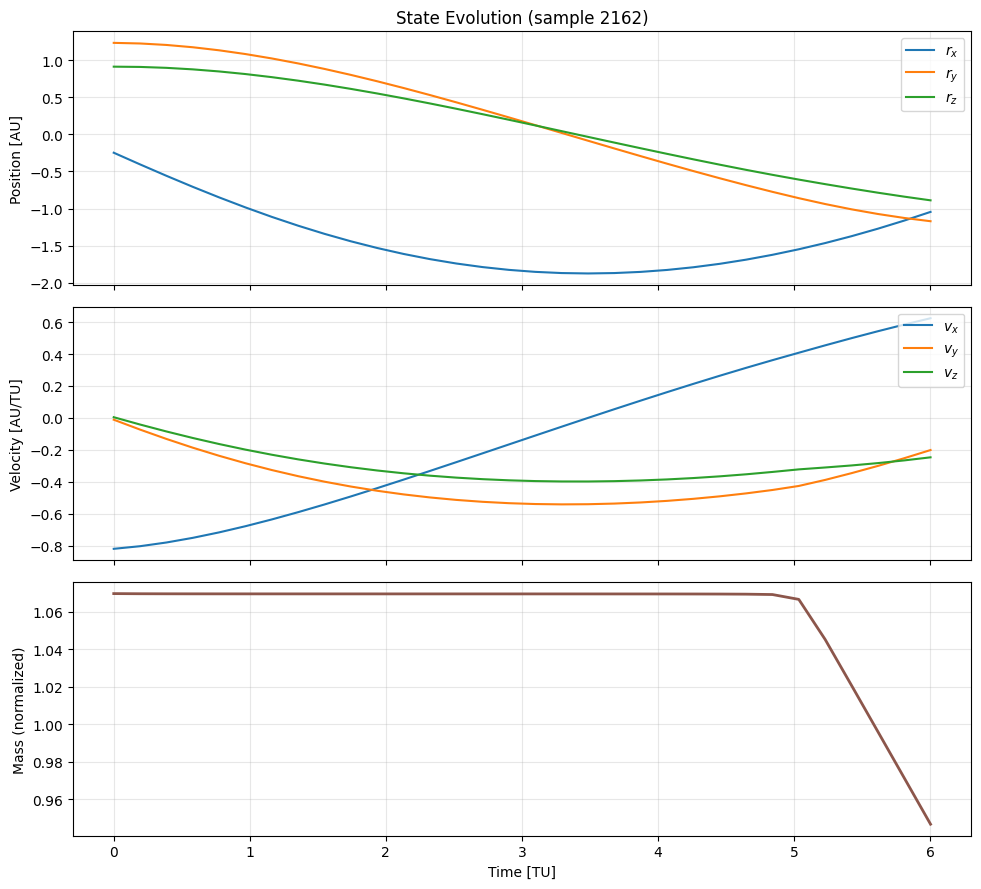

In [ ]:
# State evolution: position, velocity, mass
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

labels_r = ["$r_x$", "$r_y$", "$r_z$"]
for i in range(3):
    axes[0].plot(time_grid, r[:, i], label=labels_r[i])
axes[0].set_ylabel("Position [AU]")
axes[0].legend(loc="upper right")
axes[0].set_title(f"State Evolution (sample {idx})")
axes[0].grid(alpha=0.3)

labels_v = ["$v_x$", "$v_y$", "$v_z$"]
for i in range(3):
    axes[1].plot(time_grid, v[:, i], label=labels_v[i])
axes[1].set_ylabel("Velocity [AU/TU]")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

axes[2].plot(time_grid, mass, color="tab:brown", linewidth=2)
axes[2].set_ylabel("Mass (normalized)")
axes[2].set_xlabel("Time [TU]")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

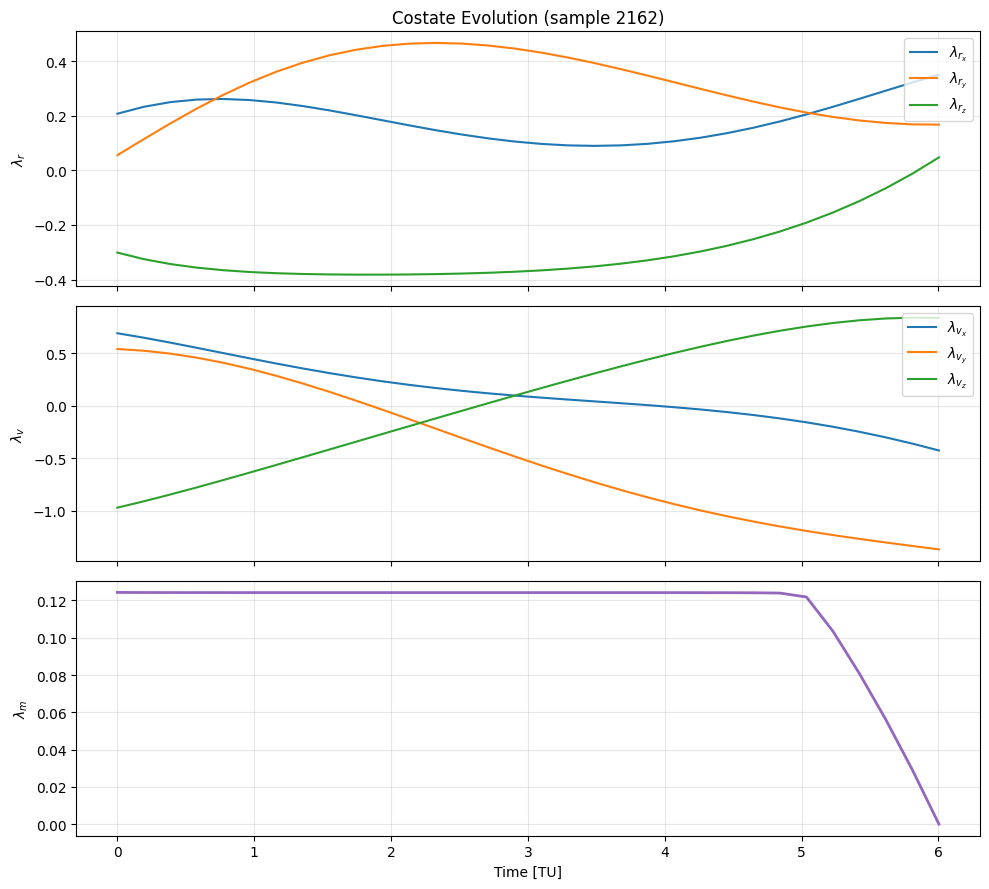

In [ ]:
# Costate evolution: λ_r, λ_v, λ_m
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

labels_lr = ["$\\lambda_{r_x}$", "$\\lambda_{r_y}$", "$\\lambda_{r_z}$"]
for i in range(3):
    axes[0].plot(time_grid, lam_r[:, i], label=labels_lr[i])
axes[0].set_ylabel("$\\lambda_r$")
axes[0].legend(loc="upper right")
axes[0].set_title(f"Costate Evolution (sample {idx})")
axes[0].grid(alpha=0.3)

labels_lv = ["$\\lambda_{v_x}$", "$\\lambda_{v_y}$", "$\\lambda_{v_z}$"]
for i in range(3):
    axes[1].plot(time_grid, lam_v[:, i], label=labels_lv[i])
axes[1].set_ylabel("$\\lambda_v$")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

axes[2].plot(time_grid, lam_m, color="tab:purple", linewidth=2)
axes[2].set_ylabel("$\\lambda_m$")
axes[2].set_xlabel("Time [TU]")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# # ── Model inference overlay (loads latest checkpoint if available) ───────────
# from pathlib import Path

# try:
#     from tqdm.auto import tqdm as _tqdm
# except ImportError:
#     def _tqdm(it, **kw): return it  # silent fallback

# # Inline peek — avoids importing generate_video.py which sets matplotlib Agg backend
# def _peek_checkpoint(raw_bytes):
#     try:
#         from flax.serialization import msgpack_restore
#     except ImportError:
#         try:
#             from flax.serialization import _msgpack_restore as msgpack_restore
#         except ImportError:
#             return None, None
#     def _s(v): return v.decode() if isinstance(v, bytes) else v
#     try:
#         raw = msgpack_restore(raw_bytes)
#         tg  = raw.get("time_grid", None)
#         sc  = raw.get("scheduler_config", None)
#         if tg is not None:
#             tg = np.asarray(tg, dtype=np.float32).ravel()
#         if sc is not None:
#             sc = {_s(k): (_s(v) if isinstance(v, bytes) else v) for k, v in sc.items()}
#         return tg, sc
#     except Exception as exc:
#         print(f"  [warn] checkpoint peek failed ({exc}); using defaults.")
#         return None, None

# checkpoint_path = Path("checkpoints/indiff_ctrl_latest.msgpack")
# if not checkpoint_path.exists():
#     print("No checkpoint found — skipping inference overlay.")
# else:
#     import jax
#     import jax.numpy as jnp
#     import optax
#     from flax import serialization
#     from core import STATE_DIM, COSTATE_DIM
#     from jax_ddpm_scheduler import JaxDDPMScheduler
#     from policy import IndiffCtrlPolicy
#     from transformer_diffusion_model import (
#         DiffusionTransformer, DiffusionTransformerConfig, final_lambda_m_costate_mask,
#     )

#     # ── Load checkpoint ───────────────────────────────────────────────────────
#     raw_bytes = checkpoint_path.read_bytes()
#     tg_ckpt, sch_raw = _peek_checkpoint(raw_bytes)
#     if tg_ckpt is None or len(tg_ckpt) < 2:
#         tg_ckpt = time_grid
#     if not sch_raw:
#         sch_raw = {}
#     def _sc(k, d):
#         v = sch_raw.get(k, d)
#         return d if v is None else v

#     seq_len = len(tg_ckpt)
#     noise_scheduler = JaxDDPMScheduler(
#         num_train_timesteps=int(_sc("num_train_timesteps", 5000)),
#         beta_schedule      =str(_sc("beta_schedule",       "squaredcos_cap_v2")),
#         prediction_type    =str(_sc("prediction_type",     "epsilon")),
#         clip_sample        =bool(_sc("clip_sample",         True)),
#         clip_sample_range  =float(_sc("clip_sample_range",  5.0)),
#         noise_scale        =float(_sc("noise_scale",        2.0)),
#     )
#     model = DiffusionTransformer(DiffusionTransformerConfig(
#         seq_len=seq_len, state_dim=STATE_DIM, costate_dim=COSTATE_DIM,
#         embd_dim=512, num_layers=12, num_heads=4, mlp_ratio=4,
#         p_drop_embd=0.0, p_drop_attn=0.0,
#         use_integration_signals=True, zero_known_state_eps=True,
#     ))
#     policy = IndiffCtrlPolicy(
#         model=model, noise_scheduler=noise_scheduler,
#         time_grid=tg_ckpt, segment_rtol=1e-7, segment_atol=1e-9,
#     )
#     key = jax.random.PRNGKey(42)
#     params_tpl = policy.init_params(key, batch_size=1)
#     opt_tpl    = optax.adamw(
#         optax.linear_schedule(1e-4, 5e-6, 1), weight_decay=1e-6
#     ).init(params_tpl)
#     loaded = serialization.from_bytes({
#         "params": params_tpl, "opt_state": opt_tpl, "step": np.int32(0),
#         "time_grid": np.zeros(seq_len, np.float32),
#         "scheduler_config": {
#             "num_train_timesteps": 5000, "beta_schedule": "squaredcos_cap_v2",
#             "prediction_type": "epsilon", "clip_sample": True,
#             "clip_sample_range": 5.0, "noise_scale": 2.0,
#         },
#     }, raw_bytes)
#     params = loaded["params"]
#     print(f"Checkpoint step={int(loaded['step'])}  seq_len={seq_len}")

#     # ── Inline denoising loop with progress bar ───────────────────────────────
#     NUM_STEPS = 30
#     cfg       = policy.model.config

#     ckm_inf          = final_lambda_m_costate_mask(1, seq_len)
#     skm_inf, ckm_inf = policy._resolve_known_masks(1, seq_len, costate_known_mask=ckm_inf)

#     cond_st       = np.zeros((1, seq_len, STATE_DIM),   np.float32)
#     cond_cs       = np.zeros((1, seq_len, COSTATE_DIM), np.float32)
#     cond_st[0, 0, :]  = states[0]
#     cond_st[0, -1, :] = states[-1]
#     cond_traj = jnp.asarray(np.concatenate([cond_st, cond_cs], axis=-1), dtype=jnp.float32)
#     cond_mask = policy._build_condition_mask(skm_inf, ckm_inf)

#     key, sk = jax.random.split(key)
#     traj = policy.noise_scheduler.sample_noise(sk, cond_traj.shape, dtype=jnp.float32)
#     policy.noise_scheduler.set_timesteps(NUM_STEPS)

#     print("Denoising (first run compiles JAX kernels — ~30–60 s; re-runs are fast):")
#     for ts in _tqdm(policy.noise_scheduler.timesteps, desc="steps", ncols=70):
#         traj = jnp.where(cond_mask, cond_traj, traj)
#         st   = traj[..., :STATE_DIM]
#         cst  = traj[..., STATE_DIM:STATE_DIM + COSTATE_DIM]

#         int_st = int_cst = int_fail = None
#         if cfg.use_integration_signals:
#             int_st, int_cst, int_fail = policy.compute_integration_signals(st, cst)

#         out = policy.model.apply(
#             {"params": params},
#             noisy_states=st, noisy_costates=cst,
#             diffusion_steps=jnp.full((1,), int(ts), dtype=jnp.int32),
#             state_known_mask=skm_inf, costate_known_mask=ckm_inf,
#             integrated_states=int_st, integrated_costates=int_cst,
#             integration_failed=int_fail, train=False,
#         )
#         model_out = policy._combine_trajectory(out["state_eps"], out["costate_eps"])
#         key, step_key = jax.random.split(key)
#         traj = policy.noise_scheduler.step(
#             model_output=model_out, timestep=int(ts),
#             sample=traj, rng_key=step_key,
#         ).prev_sample
#         traj = jnp.where(cond_mask, cond_traj, traj)   # re-pin after step

#     traj = jnp.where(cond_mask, cond_traj, traj)        # final pin

#     arr    = np.asarray(traj[0], dtype=np.float32)      # (T, 14)
#     ps     = arr[:, :STATE_DIM]
#     pc_arr = arr[:, STATE_DIM:]
#     p_r, p_v, p_mass = ps[:, :3], ps[:, 3:6], ps[:, 6]
#     p_lr, p_lv, p_lm = pc_arr[:, :3], pc_arr[:, 3:6], pc_arr[:, 6]

#     p_lv_norm = np.linalg.norm(p_lv, axis=1)
#     p_S       = c_val * p_lv_norm / np.maximum(p_mass, 1e-12) + p_lm - 1
#     p_delta   = 0.5 * (1.0 + p_S / np.sqrt(p_S**2 + eps_val))
#     p_alpha   = -p_lv / (p_lv_norm[:, None] + 1e-30)
#     p_on      = p_delta > 0.5

#     # ── 3D overlay ────────────────────────────────────────────────────────────
#     fig3d = plt.figure(figsize=(8, 7))
#     ax3d  = fig3d.add_subplot(111, projection="3d")
#     ax3d.scatter3D(0, 0, 0, color="orange", s=100, label="Sun", zorder=5)
#     ax3d.plot(r[:, 0], r[:, 1], r[:, 2], "o-", ms=3, lw=1.5, color="tab:blue", label="truth")
#     ax3d.plot(p_r[:, 0], p_r[:, 1], p_r[:, 2], "s--", ms=3, lw=1.5,
#               color="tab:orange", alpha=0.85, label="predicted")
#     ax3d.scatter(*r[0],  color="green", s=60, zorder=5)
#     ax3d.scatter(*r[-1], color="red",   s=60, zorder=5)
#     if np.any(on):
#         scale = 0.08 * np.ptp(r, axis=0).max()
#         ax3d.quiver(r[on,0], r[on,1], r[on,2], alpha[on,0], alpha[on,1], alpha[on,2],
#                     length=scale, normalize=True, color="tab:blue", alpha=0.5,
#                     label=f"truth thrust ({on.sum()})")
#     if np.any(p_on):
#         scale = 0.08 * np.ptp(r, axis=0).max()
#         ax3d.quiver(p_r[p_on,0], p_r[p_on,1], p_r[p_on,2],
#                     p_alpha[p_on,0], p_alpha[p_on,1], p_alpha[p_on,2],
#                     length=scale, normalize=True, color="darkorange", alpha=0.7,
#                     label=f"pred thrust ({p_on.sum()})")
#     ax3d.set_xlabel("x [AU]"); ax3d.set_ylabel("y [AU]"); ax3d.set_zlabel("z [AU]")
#     ax3d.set_title(f"3D Overlay — sample {idx}  (ckpt step {int(loaded['step'])})")
#     ax3d.legend(fontsize=7)
#     plt.tight_layout(); plt.show()

#     # ── State overlay ─────────────────────────────────────────────────────────
#     cols = ["tab:blue", "tab:orange", "tab:green"]
#     fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
#     for i, lb in enumerate(["$r_x$", "$r_y$", "$r_z$"]):
#         axes[0].plot(time_grid, r[:, i],   color=cols[i], lw=1.5, label=f"{lb} truth")
#         axes[0].plot(tg_ckpt,   p_r[:, i], color=cols[i], lw=1.5, ls="--", alpha=0.8, label=f"{lb} pred")
#     axes[0].set_ylabel("Position [AU]"); axes[0].legend(fontsize=7, loc="upper right")
#     axes[0].set_title(f"State Overlay — sample {idx}"); axes[0].grid(alpha=0.3)
#     for i, lb in enumerate(["$v_x$", "$v_y$", "$v_z$"]):
#         axes[1].plot(time_grid, v[:, i],   color=cols[i], lw=1.5, label=f"{lb} truth")
#         axes[1].plot(tg_ckpt,   p_v[:, i], color=cols[i], lw=1.5, ls="--", alpha=0.8, label=f"{lb} pred")
#     axes[1].set_ylabel("Velocity [AU/TU]"); axes[1].legend(fontsize=7, loc="upper right")
#     axes[1].grid(alpha=0.3)
#     axes[2].plot(time_grid, mass,   color="tab:brown", lw=2, label="truth")
#     axes[2].plot(tg_ckpt,   p_mass, color="tab:brown", lw=2, ls="--", alpha=0.8, label="pred")
#     axes[2].set_ylabel("Mass (normalized)"); axes[2].set_xlabel("Time [TU]")
#     axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)
#     plt.tight_layout(); plt.show()

#     # ── Costate overlay ───────────────────────────────────────────────────────
#     fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
#     for i, lb in enumerate(["$\\lambda_{r_x}$", "$\\lambda_{r_y}$", "$\\lambda_{r_z}$"]):
#         axes[0].plot(time_grid, lam_r[:, i], color=cols[i], lw=1.5, label=f"{lb} truth")
#         axes[0].plot(tg_ckpt,   p_lr[:, i],  color=cols[i], lw=1.5, ls="--", alpha=0.8, label=f"{lb} pred")
#     axes[0].set_ylabel("$\\lambda_r$"); axes[0].legend(fontsize=7, loc="upper right")
#     axes[0].set_title(f"Costate Overlay — sample {idx}"); axes[0].grid(alpha=0.3)
#     for i, lb in enumerate(["$\\lambda_{v_x}$", "$\\lambda_{v_y}$", "$\\lambda_{v_z}$"]):
#         axes[1].plot(time_grid, lam_v[:, i], color=cols[i], lw=1.5, label=f"{lb} truth")
#         axes[1].plot(tg_ckpt,   p_lv[:, i],  color=cols[i], lw=1.5, ls="--", alpha=0.8, label=f"{lb} pred")
#     axes[1].set_ylabel("$\\lambda_v$"); axes[1].legend(fontsize=7, loc="upper right")
#     axes[1].grid(alpha=0.3)
#     axes[2].plot(time_grid, lam_m, color="tab:purple", lw=2, label="truth")
#     axes[2].plot(tg_ckpt,   p_lm,  color="tab:purple", lw=2, ls="--", alpha=0.8, label="pred")
#     axes[2].set_ylabel("$\\lambda_m$"); axes[2].set_xlabel("Time [TU]")
#     axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)
#     plt.tight_layout(); plt.show()


Earth orbital period: 6.2877 TU  (1.0007 yr)
Mars  orbital period: 11.8252 TU  (1.8820 yr)
Transfer time:        6.0042 TU  (0.9556 yr)

Mars arrival check — propagated vs given:
  r_f given:      [-1.154292  1.182884  0.053134]
  r_f propagated: [-1.154292  1.182884  0.053134]
  error: 1.26e-11 AU


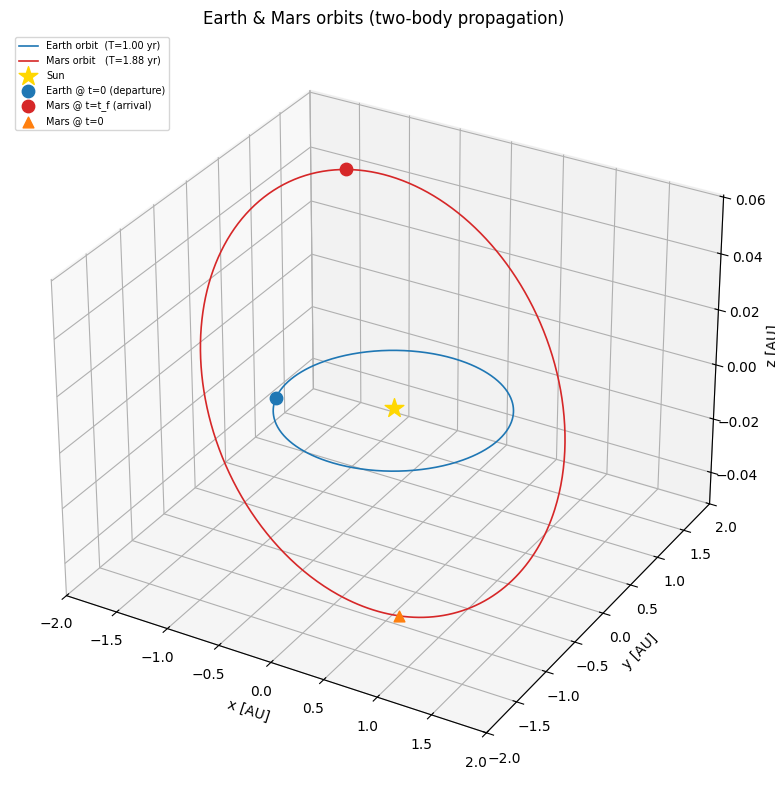

In [2]:

# ── Propagate Earth & Mars orbits ─────────────────────────────────────────────
# Uses scipy DOP853 (two-body, no thrust) to recover each planet's full orbit.
#
# Earth:  propagate forward from (r_i, v_i) at t=0 for one orbital period.
# Mars :  back-propagate from (r_f, v_f) at t=t_f to find Mars state at t=0,
#         then propagate forward for one orbital period.
#
# Units: AU / TU  (TU = 1/(2π) yr,  μ ≈ 0.9986)

from scipy.integrate import solve_ivp
from core import build_normalization
import numpy as np
import matplotlib.pyplot as plt

norm = build_normalization()
mu   = float(norm["mu"])
t_f  = float(norm["t_f"])
r_i  = np.asarray(norm["r_i"], dtype=np.float64)
v_i  = np.asarray(norm["v_i"], dtype=np.float64)
r_f  = np.asarray(norm["r_f"], dtype=np.float64)
v_f  = np.asarray(norm["v_f"], dtype=np.float64)

def two_body(t, y):
    r, v = y[:3], y[3:]
    return np.concatenate([v, -mu / np.linalg.norm(r)**3 * r])

def orbital_period(r, v):
    """Keplerian period from vis-viva."""
    E = 0.5 * np.dot(v, v) - mu / np.linalg.norm(r)   # specific energy
    a = -mu / (2.0 * E)                                  # semi-major axis
    return 2.0 * np.pi * np.sqrt(a**3 / mu)

# ── Earth orbit (starts at t=0) ───────────────────────────────────────────────
T_earth   = orbital_period(r_i, v_i)
t_earth   = np.linspace(0, T_earth, 500)
sol_earth = solve_ivp(two_body, [0, T_earth], np.concatenate([r_i, v_i]),
                      method="DOP853", t_eval=t_earth, rtol=1e-11, atol=1e-13)
r_earth   = sol_earth.y[:3].T   # (500, 3)

# ── Mars at t=0: back-propagate from arrival (r_f, v_f) by t_f ───────────────
sol_back  = solve_ivp(two_body, [t_f, 0.0], np.concatenate([r_f, v_f]),
                      method="DOP853", rtol=1e-11, atol=1e-13)
r_mars_0  = sol_back.y[:3, -1]
v_mars_0  = sol_back.y[3:,  -1]

T_mars    = orbital_period(r_mars_0, v_mars_0)
t_mars    = np.linspace(0, T_mars, 500)
sol_mars  = solve_ivp(two_body, [0, T_mars], np.concatenate([r_mars_0, v_mars_0]),
                      method="DOP853", t_eval=t_mars, rtol=1e-11, atol=1e-13)
r_mars    = sol_mars.y[:3].T    # (500, 3)

# ── Mars position at t=t_f (propagate from t=0 to t=t_f) ─────────────────────
sol_mars_at_tf = solve_ivp(two_body, [0, t_f], np.concatenate([r_mars_0, v_mars_0]),
                            method="DOP853", rtol=1e-11, atol=1e-13)
r_mars_tf_check = sol_mars_at_tf.y[:3, -1]

print(f"Earth orbital period: {T_earth:.4f} TU  ({T_earth/(2*np.pi):.4f} yr)")
print(f"Mars  orbital period: {T_mars:.4f} TU  ({T_mars /(2*np.pi):.4f} yr)")
print(f"Transfer time:        {t_f:.4f} TU  ({t_f/(2*np.pi):.4f} yr)")
print(f"\nMars arrival check — propagated vs given:")
print(f"  r_f given:      {r_f.round(6)}")
print(f"  r_f propagated: {r_mars_tf_check.round(6)}")
print(f"  error: {np.linalg.norm(r_mars_tf_check - r_f):.2e} AU")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 8))
ax  = fig.add_subplot(111, projection="3d")

ax.plot(*r_earth.T, color="tab:blue",  lw=1.2, label=f"Earth orbit  (T={T_earth/(2*np.pi):.2f} yr)")
ax.plot(*r_mars.T,  color="tab:red",   lw=1.2, label=f"Mars orbit   (T={T_mars/(2*np.pi):.2f} yr)")

ax.scatter(0, 0, 0,       color="gold",       s=200, marker="*", zorder=5, label="Sun")
ax.scatter(*r_i,           color="tab:blue",   s=80,              zorder=5, label=f"Earth @ t=0 (departure)")
ax.scatter(*r_f,           color="tab:red",    s=80,              zorder=5, label=f"Mars @ t=t_f (arrival)")
ax.scatter(*r_mars_0,      color="tab:orange", s=60,  marker="^", zorder=5, label="Mars @ t=0")

ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]"); ax.set_zlabel("z [AU]")
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_title("Earth & Mars orbits (two-body propagation)")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()
